# Logistic Regression

Prerequisites

Ensure you have the following libraries installed:

pandas, numpy, matplotlib, seaborn, scikit-learn

**2. Environment Setup & Data Loading**

Logistic Regression predicts the probability of a categorical target. We'll start by loading our classification dataset.

Importing the Library Stack
numpy & pandas: The "bread and butter" for handling arrays and tabular data.

matplotlib & seaborn: Used for statistical visualization (checking for correlations or distributions).

load_breast_cancer: A built-in Scikit-Learn dataset containing 569 instances with 30 numeric features (like tumor radius, texture, and perimeter).

StandardScaler: Essential here because tumor measurements vary in scale (e.g., area vs. smoothness).

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

data.data: This is a raw NumPy array containing the 30 measurements.

data.feature_names: These are the column headers (e.g., "mean radius", "mean concavity").

df['target']: You are adding a column for the ground truth. In machine learning, this is the "answer key" the model tries to predict.

In [2]:
# Load the dataset
data = load_breast_cancer()
df = pd.DataFrame(data.data, columns=data.feature_names)
df['target'] = data.target



**Understanding the Target Classes**
In classification, knowing which number represents which class is critical:

Class 0 (Malignant): Represents harmful tumors.

Class 1 (Benign): Represents non-harmful tumors.

In [3]:
# Target mapping: 0 = Malignant, 1 = Benign
print("Target Classes:", data.target_names)
print(df.head())

Target Classes: ['malignant' 'benign']
   mean radius  mean texture  mean perimeter  mean area  mean smoothness  \
0        17.99         10.38          122.80     1001.0          0.11840   
1        20.57         17.77          132.90     1326.0          0.08474   
2        19.69         21.25          130.00     1203.0          0.10960   
3        11.42         20.38           77.58      386.1          0.14250   
4        20.29         14.34          135.10     1297.0          0.10030   

   mean compactness  mean concavity  mean concave points  mean symmetry  \
0           0.27760          0.3001              0.14710         0.2419   
1           0.07864          0.0869              0.07017         0.1812   
2           0.15990          0.1974              0.12790         0.2069   
3           0.28390          0.2414              0.10520         0.2597   
4           0.13280          0.1980              0.10430         0.1809   

   mean fractal dimension  ...  worst texture  worst 

**Exploratory Data Analysis (EDA) for Classification**

In classification, we are interested in how features separate the classes.

Tasks:

Check Class Balance: Use df['target'].value_counts() to see if one class dominates.

Feature Distribution by Class: Compare how a feature like mean radius differs between Malignant and Benign cases.

**Class Balance Visualization**
This creates a bar chart showing how many "Malignant" (0) vs. "Benign" (1) cases exist in the dataset.

Why it matters: If one class is much larger than the other (e.g., 90% Benign, 10% Malignant), a model might become lazy and just predict "Benign" every time to get a high accuracy. This is called Class Imbalance.

/tmp/ipykernel_2775/2627260163.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='target', data=df, palette='viridis')


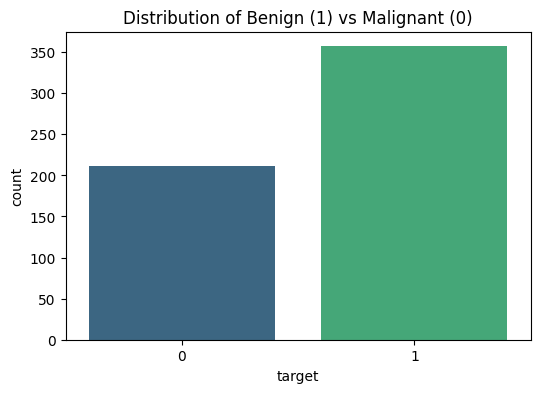

In [4]:
# 1. Class Balance Visualization
plt.figure(figsize=(6, 4))
sns.countplot(x='target', data=df, palette='viridis')
plt.title("Distribution of Benign (1) vs Malignant (0)")
plt.show()


**Density (KDE) Plot for Feature Separability**
A Kernel Density Estimate (KDE) is essentially a smoothed version of a histogram. It shows the "shape" of the data for a specific feature—in this case, mean radius.

The Comparison: It plots two overlapping curves:

Malignant curve: Usually shifted toward the right (larger radius).

Benign curve: Usually shifted toward the left (smaller radius).

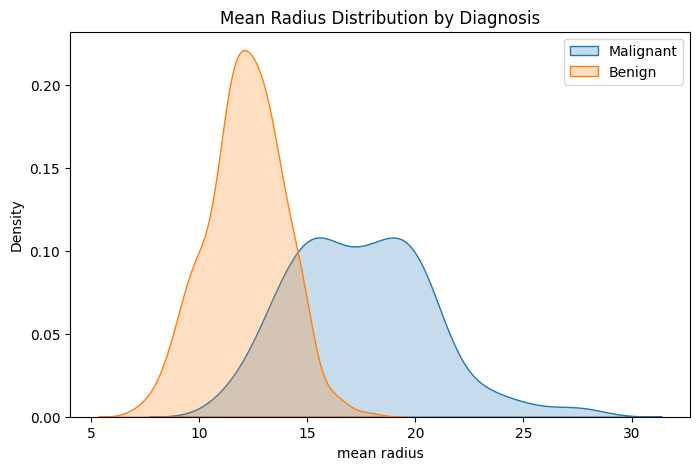

In [5]:
# 2. Distribution Plot
plt.figure(figsize=(8, 5))
sns.kdeplot(df[df['target'] == 0]['mean radius'], label='Malignant', fill=True)
sns.kdeplot(df[df['target'] == 1]['mean radius'], label='Benign', fill=True)
plt.title("Mean Radius Distribution by Diagnosis")
plt.legend()
plt.show()

**Data Preprocessing**

Logistic Regression is sensitive to the scale of features because it uses optimization algorithms (like Coordinate Descent) to find the best coefficients.

Tasks:

Split Data: Separate into features ($X$) and target ($y$).

Feature Scaling: Apply StandardScaler so all features have a mean of 0 and a variance of 1.

In [6]:
# Define X and y
X = df.drop('target', axis=1)
y = df['target']

In [7]:
# Split into Training and Testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [8]:
# Apply Scaling
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [9]:
print("Original Feature Mean:", X_train.iloc[:,0].mean())
print("Scaled Feature Mean:", X_train_scaled[:,0].mean())

Original Feature Mean: 14.117635164835166
Scaled Feature Mean: -1.811493568091684e-15


**Feature Selection for Logistic Regression**

High multicollinearity (when features are highly correlated) can make Logistic Regression coefficients unstable.

**Calculating the Correlation Matrix**

df.corr(): This computes the Pearson Correlation Coefficient for every pair of columns in your dataframe. It results in a table (matrix) of numbers ranging from -1.0 to +1.0.

['target']: Since you only care about what predicts cancer, you filter the matrix to only look at the column that shows how features relate to the target.

.sort_values(ascending=False)
This sorts the list so that the features with the highest positive correlation appear at the top.



In [10]:
# Correlation with Target
correlations = df.corr()['target'].sort_values(ascending=False)
print("Top 5 Features Correlated with Target:")
print(correlations.head(6)) # Including target itself


Top 5 Features Correlated with Target:
target                     1.000000
smoothness error           0.067016
mean fractal dimension     0.012838
texture error              0.008303
symmetry error             0.006522
fractal dimension error   -0.077972
Name: target, dtype: float64


**Handling Missing Data (Imputation)**

Real-world data often has gaps. Logistic Regression in scikit-learn will fail if the input contains NaN values. We will use SimpleImputer to fill these gaps.

In [11]:
import numpy as np
import pandas as pd
from sklearn.datasets import load_breast_cancer
from sklearn.impute import SimpleImputer
from sklearn.model_selection import train_test_split

In [12]:
# Load data
data = load_breast_cancer()
X = pd.DataFrame(data.data, columns=data.feature_names)
y = data.target



**Creating the Problem (Artificial Noise)**
To practice handling missing data, the code deliberately ruins the first 10 rows of the first column (mean radius) by setting them to np.nan (Not a Number).

In [13]:
# Introducing artificial missing values for practice
X_missing = X.copy()
X_missing.iloc[0:10, 0] = np.nan  # Set first 10 rows of 'mean radius' to NaN



**The Solution: SimpleImputer**

Nstead of deleting valuable medical records just because one measurement is missing, we use Imputation to guess the missing value.

The Strategy ('mean'): It calculates the average of all existing values in that column and plugs that average into the 10 missing slots.

fit: The imputer "learns" the mean of the column.

transform: It actually fills in the blanks.

In [14]:
# Task: Apply Imputation
# We use 'mean' strategy for continuous biological data
imputer = SimpleImputer(strategy='mean')
X_imputed = imputer.fit_transform(X_missing)



In [15]:
print(f"Missing values after imputation: {np.isnan(X_imputed).sum()}")

Missing values after imputation: 0


This confirms that the X_imputed array is now "clean" and ready to be fed into a machine learning model.

**Dimensionality Reduction (PCA)**

The Breast Cancer dataset has 30 features. Many are highly correlated (e.g., radius, perimeter, and area). We can use PCA to reduce these to a few "Principal Components" while retaining most of the information.

Task: Visualizing Variance

We need to determine how many components are necessary to capture the majority of the data's variance.

In [16]:
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

Load the 30 features of the Breast Cancer dataset into a DataFrame.

Artificial Corruption: To simulate a real-world problem, the code deliberately deletes the first 10 values of the mean radius column. If you tried to train a model right now, it would throw an error.

In [17]:
# Scaling is mandatory for PCA
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_imputed)

By not specifying n_components, PCA calculates all 30 possible components (one for every feature).

The Goal: We aren't trying to reduce the data yet; we are "interrogating" the data to see which directions hold the most signal.

In [18]:
# Apply PCA
pca = PCA()
pca.fit(X_scaled)

PCA()

explained_variance_ratio_: This tells you how much "information" each component captures.

np.cumsum: This calculates the running total. If the first 3 components cover 70% of the variance, the plot shows 0.7 at index 3.

plt.axhline(y=0.95, color='r', linestyle='--')
The Threshold: This draws a red dashed line at 95%. In PhD-level research, 95% is a common industry standard for "retaining enough information" while discarding noise.

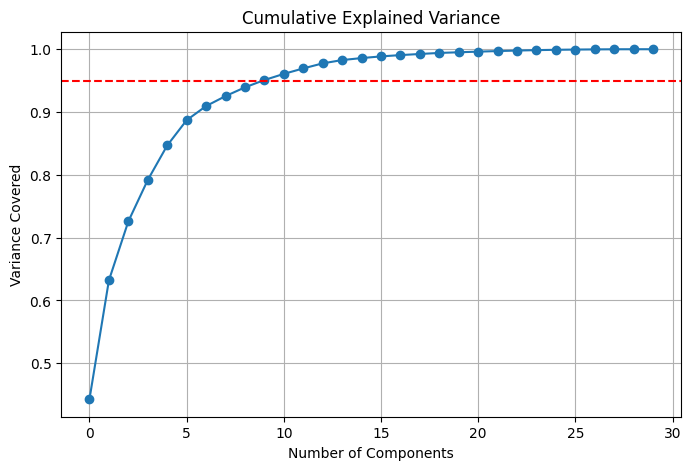

In [19]:
# Scree Plot
plt.figure(figsize=(8, 5))
plt.plot(np.cumsum(pca.explained_variance_ratio_), marker='o')
plt.axhline(y=0.95, color='r', linestyle='--')
plt.title('Cumulative Explained Variance')
plt.xlabel('Number of Components')
plt.ylabel('Variance Covered')
plt.grid()
plt.show()

**Transforming the Dataset**

Based on the plot above, we can usually capture >95% of the variance with fewer than 10 components.

Based on your previous "Scree Plot" analysis, you’ve decided that 5 components are sufficient to represent the core patterns of the 30 measurements.

The Action: fit_transform projects your high-dimensional data (30 features) into a new, simplified 5-dimensional space. These 5 components are Orthogonal, meaning they are mathematically independent of each other (no redundancy).

In [20]:
# Reducing to 5 components
pca_final = PCA(n_components=5)
X_pca = pca_final.fit_transform(X_scaled)

This confirms that you have successfully compressed the data. Your model now only has to process 5 columns instead of 30. This significantly reduces the risk of Overfitting and makes future training much faster.

In [21]:
print(f"Original shape: {X_scaled.shape}")
print(f"Reduced shape: {X_pca.shape}")

Original shape: (569, 30)
Reduced shape: (569, 5)


pca_final.components_[0]: This retrieves the weights (eigenvectors) for the very first principal component (PC1).

Features like concave points or perimeter often have high loadings in PC1 for breast cancer. This suggests that PC1 is likely a "Size and Shape" component.

In [22]:
# Viewing component loadings (Which features drive PC1?)
loadings = pd.DataFrame(pca_final.components_[0], index=data.feature_names, columns=['PC1'])
print(loadings.sort_values(by='PC1', ascending=False).head())

                           PC1
mean concave points   0.260793
mean concavity        0.258451
worst concave points  0.250858
mean compactness      0.239472
worst perimeter       0.236419


**Modeling on Reduced Data**

Now we train a Logistic Regression model on the 5 PCA components instead of the 30 raw features.

In [23]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

In [24]:
X_train, X_test, y_train, y_test = train_test_split(X_pca, y, test_size=0.2, random_state=42)

Despite its name, Logistic Regression is for classification, not regression. It calculates the probability that a data point belongs to "Class 1" (Benign).

The Math: It uses a Sigmoid Function to squash any numerical input into a value between 0 and 1. If the result is $> 0.5$, it predicts Benign; otherwise, it predicts Malignant.

In [25]:
clf = LogisticRegression()
clf.fit(X_train, y_train)

LogisticRegression()

The model is now given the 5 PCA components of the "unseen" test patients. It uses the logic it learned during training to guess whether each tumor is 0 or 1.

Next Step: In a real lab scenario, you would compare y_pred (the guesses) against y_test (the actual truth) to calculate your accuracy.

In [26]:
y_pred = clf.predict(X_test)


In [27]:
print(f"Model Accuracy (5 PCA Components): {accuracy_score(y_test, y_pred):.4f}")

Model Accuracy (5 PCA Components): 0.9825


# Comparisons

 Theoretical Difference

Linear Regression: Predicts a continuous output $y$ based on the formula $y = \beta_0 + \beta_1x$. The output can be any real number ($-\infty$ to $+\infty$).

Logistic Regression: Predicts the probability of a class. It uses the Logit function to map the linear equation to a value between $0$ and $1$:

$$P(y=1|x) = \frac{1}{1 + e^{-(\beta_0 + \beta_1x)}}$$

**Dataset Preparation**
Use the Breast Cancer dataset. To make the comparison clear, we will attempt to predict the target using only one highly correlated feature: mean concave points.

In [28]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.datasets import load_breast_cancer
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

Instead of using all 30 features, you are picking index 7. In the Breast Cancer dataset, this is "mean concave points."

Scientific Insight: As you saw in your previous correlation lab, this specific feature is one of the strongest predictors of malignancy.

reshape(-1, 1): Scikit-learn expects a 2D array (a table with rows and columns) for the input X. Since you are only using one feature, you must "reshape" it from a simple list into a column vector.

In [29]:
# Load data
data = load_breast_cancer()
X = data.data[:, 7].reshape(-1, 1) # 'mean concave points'
y = data.target

You are reserving 20% of the data to test if the model can predict cancer in new patients. Using a random_state ensures that your results are consistent every time you run the code.

fit_transform: The scaler calculates the average (mean) and spread (standard deviation) of the training data and then shifts the data so that it centers around 0.

transform: You apply the exact same math to the test data.

Why Scale for a Single Feature? Even with one feature, scaling helps the optimization algorithms (like the "solvers" we discussed) converge much faster and prevents mathematical overflow errors.


In [30]:
# Split and Scale
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

**Implementation: Linear vs. Logistic**

Task: Fitting both models

We will fit a Linear Regression model (treating $0$ and $1$ as continuous numbers) and a Logistic Regression model.

In [31]:
# Linear Regression
lin_reg = LinearRegression()
lin_reg.fit(X_train_scaled, y_train)
y_pred = lin_reg.predict(X_test_scaled)

In [32]:
# Logistic Regression
log_reg = LogisticRegression()
log_reg.fit(X_train_scaled, y_train)
y_pred_prob = log_reg.predict_proba(X_test_scaled)[:, 1]

**Visual Comparison**

The best way to see the difference is by plotting the "Prediction Line" vs. the "Prediction Curve".

To draw smooth lines, you need more than just your original data points. np.linspace creates 300 evenly spaced points across the entire spectrum of your "Mean Concave Points."

The Goal: This provides the "canvas" on which both models will draw their predictions.

In [33]:
# Generate points for the plot
X_range = np.linspace(X_train_scaled.min(), X_train_scaled.max(), 300).reshape(-1, 1)
y_pred_lin = lin_reg.predict(X_range)

Linear Regression: It outputs a continuous value. As you’ll see in the plot, these values often go below 0 or above 1.

Logistic Regression (predict_proba): Instead of just saying "0" or "1", you are asking for the probability. [:, 1] specifically asks for the probability of the tumor being Benign (Class 1).

In [34]:
# Get predictions
y_lin_pred = lin_reg.predict(X_range)
y_log_prob = log_reg.predict_proba(X_range)[:, 1]



The Scatter Plot: Shows the actual patients. They are clustered at the bottom (Malignant=0) and the top (Benign=1).

The Red Line (Linear): It cuts straight through the middle. Note how it "overshoots"—predicting values like $1.2$ for very clear benign cases, which is mathematically nonsensical for a binary label.

The Blue Curve (Logistic): This is the Sigmoid Curve. It flattens out at 0 and 1, perfectly staying within the bounds of probability.

plt.axhline(0.5, color='black', linestyle='--', label='Decision Threshold')
This is the "Cut-off." Any point where the blue curve is above this line results in a "Benign" prediction.

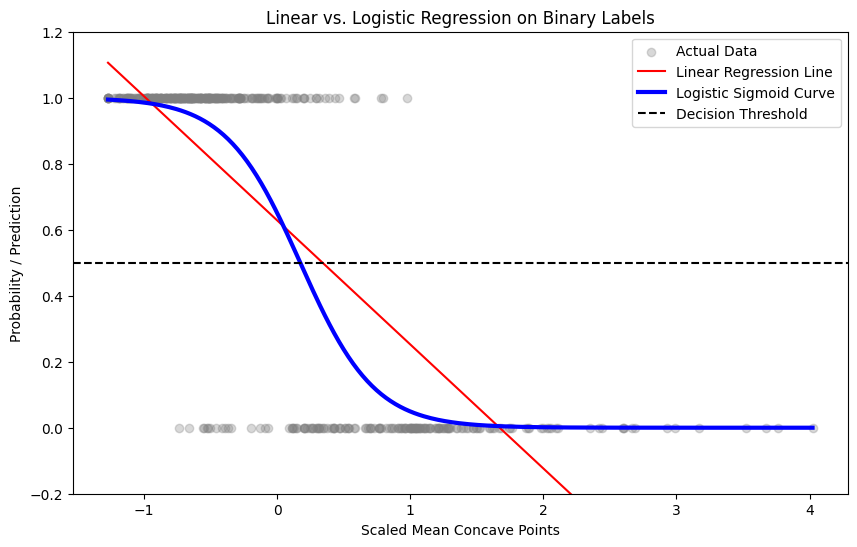

In [35]:
# Plotting
plt.figure(figsize=(10, 6))
plt.scatter(X_train_scaled, y_train, color='gray', alpha=0.3, label='Actual Data')
plt.plot(X_range, y_lin_pred, color='red', label='Linear Regression Line')
plt.plot(X_range, y_log_prob, color='blue', linewidth=3, label='Logistic Sigmoid Curve')

plt.axhline(0.5, color='black', linestyle='--', label='Decision Threshold')
plt.ylim(-0.2, 1.2)
plt.xlabel('Scaled Mean Concave Points')
plt.ylabel('Probability / Prediction')
plt.title('Linear vs. Logistic Regression on Binary Labels')
plt.legend()
plt.show()

**Probability vs. Decision Making**

One major advantage of Logistic Regression is the ability to interpret the output as a confidence level.

You are pulling the very first patient ([0]) from your test set.

The Format: Just like during training, Scikit-Learn requires a 2-dimensional input. reshape(1, -1) takes that single data point and turns it into a "row" so the model can process it.

In [36]:
# Comparing raw outputs for a sample point
sample_x = X_test_scaled[0].reshape(1, -1)



Linear Regression calculates the output using the formula $y = mx + b$.The Result: It returns a raw number. If the patient has very high "concave points," the linear model might return 1.25.

The Problem: In a world where 0 is "Cancer" and 1 is "Healthy," what does 1.25 mean? It is mathematically "out of bounds" and difficult to interpret clinically.

In [37]:

lin_val = lin_reg.predict(sample_x)[0]




Logistic Regression takes that same linear result and passes it through the Sigmoid Function.

The Result: It returns a probability between 0 and 1.

[0, 1]: predict_proba returns two values per point: the probability of class 0 and the probability of class 1. This index specifically grabs the probability of the tumor being Benign (Class 1).

In [38]:
log_prob = log_reg.predict_proba(sample_x)[0, 1]

In [39]:
print(f"Linear Prediction: {lin_val:.4f}")
print(f"Logistic Probability: {log_prob:.4f}")

Linear Prediction: 0.7282
Logistic Probability: 0.8282


**Outlier Sensitivity Test**

Linear Regression is highly sensitive to outliers because the MSE penalty squares the error.

The Data: You are adding a patient with a "Mean Concave Point" value of 10. Since your data is scaled (mean=0, std=1), a value of 10 is an extreme outlier (10 standard deviations away).

The Label: You label this extreme case as 0 (Malignant).

The Goal: This creates a "heavy" point far to the right of the graph that will try to "pull" the models toward it.

In [40]:
# Adding an extreme outlier
X_outlier = np.append(X_train_scaled, [[10]], axis=0) # Extreme high value
y_outlier = np.append(y_train, [0]) # Labeled as 0


Linear Regression tries to minimize the distance to all points. Because the outlier is so far away, the "lever arm" effect is huge. The entire line will tilt significantly just to accommodate this one weird data point.

Logistic Regression focuses on the "Decision Zone" (the middle). Because the outlier is far to the right and already clearly in the "Malignant" zone, the model essentially says, "I already knew that area was malignant," and largely ignores it.

In [41]:
# Re-fitting
lin_reg_outlier = LinearRegression().fit(X_outlier, y_outlier)
log_reg_outlier = LogisticRegression().fit(X_outlier, y_outlier)

This calculates how much the prediction at the center ($X=0$) moved because of that one outlier.

Expected Result: You will likely see a significant "Linear shift." The straight line is forced to change its slope and intercept globally to account for the outlier.

In [42]:
# Compare shifts in predictions at X=0
print(f"Linear shift: {lin_reg_outlier.predict([[0]])[0] - lin_reg.predict([[0]])[0]:.4f}")
print(f"Logistic shift: {log_reg_outlier.predict_proba([[0]])[0,1] - log_reg.predict_proba([[0]])[0,1]:.4f}")

Linear shift: 0.0056
Logistic shift: -0.0000


**Evaluation Metrics**

We use different tools to measure success based on the output type.

 Since Linear Regression predicts a continuous number, we measure the distance between the predicted point and the actual label (0 or 1).

 The Math: $MSE = \frac{1}{n} \sum (y_{actual} - y_{predicted})^2$.

 The Problem: In classification, a "large distance" doesn't always mean a "bad guess." If the label is 1 and the linear model predicts 1.5, the MSE penalizes the model for being "too right," which is why MSE is a poor metric for binary diagnosis.

In [43]:
from sklearn.metrics import mean_squared_error, accuracy_score, log_loss

# Linear Evaluation (using MSE)
lin_pred_test = lin_reg.predict(X_test_scaled)
print(f"Linear Regression MSE: {mean_squared_error(y_test, lin_pred_test):.4f}")

Linear Regression MSE: 0.0959


This is the most intuitive metric. It asks: "Out of 100 patients, how many did the model diagnose correctly?"

The Limit: Accuracy only cares about the final "Yes/No" decision. It doesn't tell you how confident the model was in those decisions.

In [44]:
# Logistic Evaluation (using Accuracy and Log Loss)
log_pred_test = log_reg.predict(X_test_scaled)
log_prob_test = log_reg.predict_proba(X_test_scaled)
print(f"Logistic Accuracy: {accuracy_score(y_test, log_pred_test):.4f}")
print(f"Logistic Log Loss: {log_loss(y_test, log_prob_test):.4f}")

Logistic Accuracy: 0.8772
Logistic Log Loss: 0.2237
